In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [5]:
df = pd.read_csv('../StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

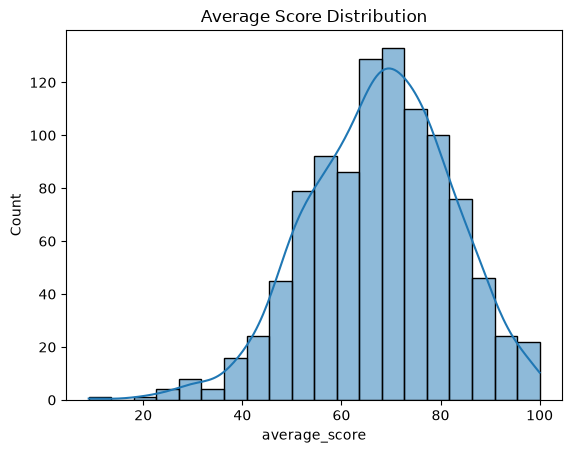

In [7]:
sns.histplot(df['average_score'], kde=True, bins=20)
plt.title('Average Score Distribution')
plt.show()

In [8]:
X = df.drop(columns=['math score', 'reading score', 'writing score', 'average_score'])
y = df['average_score']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Final X columns:", X.columns.tolist())

Final X columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22036\3128724422.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, reg in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', reg)])
    models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
    }

    results = {}

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for name, reg in models.items():
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', reg)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    results_df = pd.DataFrame(results).T
    print(results_df)
    y_pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T
print(results_df)

                         MAE       RMSE        R2
Linear Regression  10.490182  13.401580  0.162172
Decision Tree      11.880278  15.252603 -0.085253
Random Forest      11.481224  14.777533 -0.018701
                         MAE       RMSE        R2
Linear Regression  10.490182  13.401580  0.162172
Decision Tree      11.880278  15.252603 -0.085253
Random Forest      11.481224  14.777533 -0.018701
                         MAE       RMSE        R2
Linear Regression  10.490182  13.401580  0.162172
Decision Tree      11.880278  15.252603 -0.085253
Random Forest      11.481224  14.777533 -0.018701
                         MAE       RMSE        R2
Linear Regression  10.490182  13.401580  0.162172
Decision Tree      11.880278  15.252603 -0.085253
Random Forest      11.481224  14.777533 -0.018701


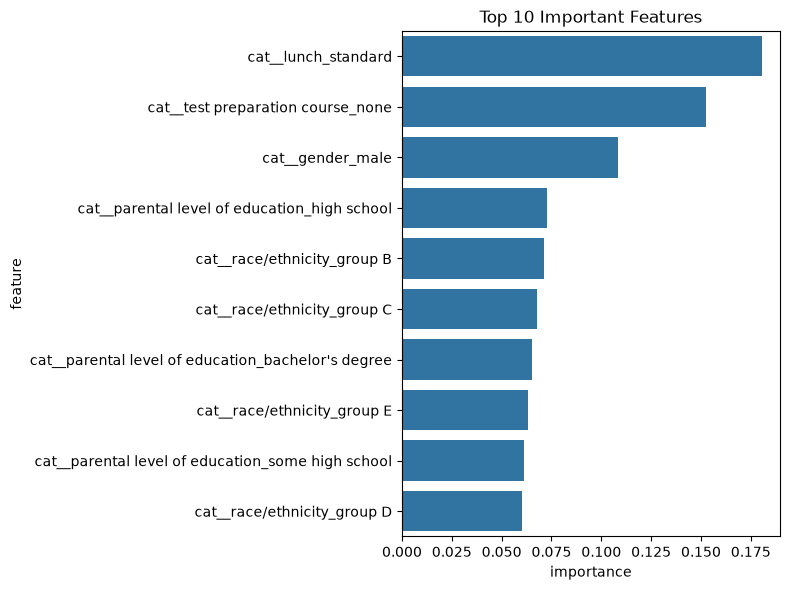

In [12]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)

importances = rf_model.named_steps['regressor'].feature_importances_
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feat_df.head(10))
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

In [13]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

final_model.fit(X_train, y_train)

joblib.dump(final_model, 'student_performance_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [14]:
def predict_average_score(gender, race_ethnicity, parental_education, lunch, test_prep):
    input_df = pd.DataFrame({
        'gender': [gender],
        'race/ethnicity': [race_ethnicity],
        'parental level of education': [parental_education],
        'lunch': [lunch],
        'test preparation course': [test_prep]
    })
    prediction = final_model.predict(input_df)
    return round(prediction[0], 2)

result = predict_average_score(
    gender='female',
    race_ethnicity='group B',
    parental_education="bachelor's degree",
    lunch='standard',
    test_prep='completed'
)
print(f"Predicted Average Score: {result}")

Predicted Average Score: 80.84
